# Actividad: Explorando Imágenes de Fondo de Ojo como Matrices

## Procesamiento de Imágenes Médicas con Python, NumPy y Matplotlib

**Objetivos de aprendizaje:** 
-Comprender que una imagen digital puede representarse como una matriz. -Manipular directamente los valores de los píxeles utilizando Python.
-Analizar histogramas para entender la distribución de intensidades.
-Aplicar transformaciones matemáticas para mejorar o modificar una imagen médica.

### Parte 1 - Explorando la imágen como matriz

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

Cargar y mostrar imagen

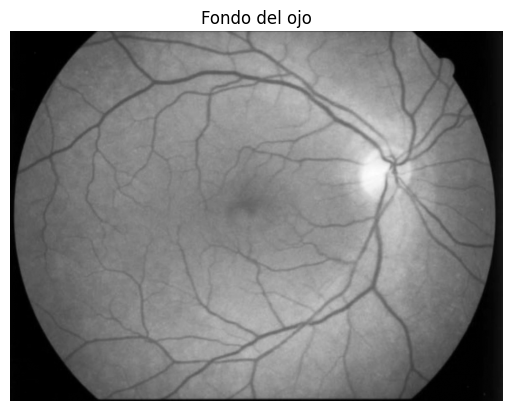

In [8]:
url='https://udocz-cdn-hop.b-cdn.net/documents_html/321333-f8a987eef516aafd2a41c7166426713e/bg1.jpg'
resp=urllib.request.urlopen(url)
image=np.asarray(bytearray(resp.read()),dtype="uint8")
imagen=cv2.imdecode(image,cv2.IMREAD_GRAYSCALE)

plt.imshow(imagen, cmap='gray')
plt.title('Fondo del ojo')
plt.axis("off")
plt.show()

Tamaño de la matriz de la imagen

In [11]:
imagen.shape

(1080, 1440)

Valor del pixel en la posición (200,200)

In [10]:
pixel = imagen[200,200]
print("Valor del pixel en (200,200):", pixel)

Valor del pixel en (200,200): 83


Valor minimo y maximo de intensidad de la imagen

In [12]:
minimo = np.min(imagen)
maximo = np.max(imagen)

print("Valor mínimo de intensidad:", minimo)
print("Valor máximo de intensidad:", maximo)

Valor mínimo de intensidad: 0
Valor máximo de intensidad: 199


### Parte 2 - Manipulación directa de la matriz 

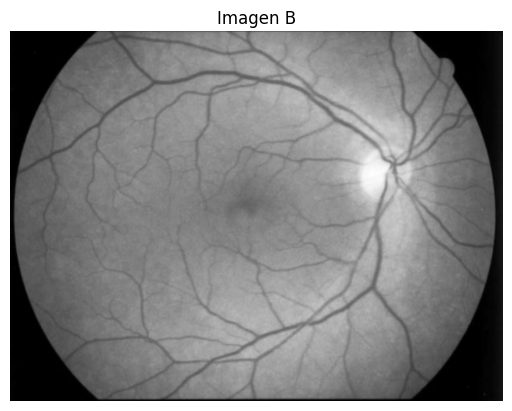

In [18]:
A = imagen
B = np.zeros(A.shape, dtype=np.uint8)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        B[i,j] = 0.5 * A[i,j]

plt.imshow(B, cmap='gray')
plt.title("Imagen B")
plt.axis("off")
plt.show()

***Preguntas:***

**1. ¿Cómo cambió el brillo de la imagen?**
El brillo de la imagen disminuyó. Debido a que todos los valores de intensidad de los píxeles fueron multiplicados por 0.5, lo que redujo su valor a la mitad.

**2. ¿Qué pasó con la visibilidad de los vasos sanguíneos?**
Los vasos sanguíneos siguen siendo visibles, pero se observan ligeramente menos definidos. Al reducir la intensidad de todos los píxeles también se reduce el contraste general de la imagen, lo que hace que algunas estructuras como los vasos sanguíneos se perciban un poco menos marcadas.

### Parte 3 - Transformación logarítmica

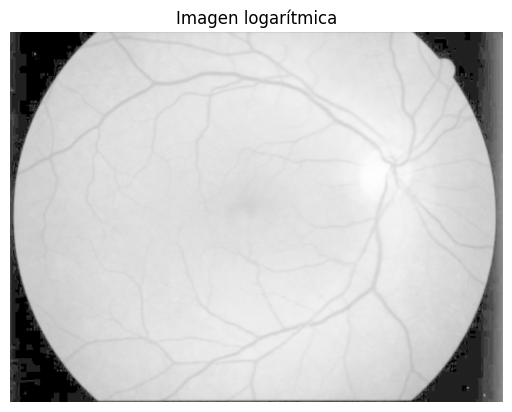

In [20]:
B = np.zeros(A.shape) #Crear matriz para nueva imagen

# Transformación log
for i in range(A.shape[0]): #Recorrer las filas
    for j in range(A.shape[1]): #Recorrer las columnas
        B[i,j] = np.log10(A[i,j] + 1) #Aplicar transformación

# obtener min y max
min_val = np.min(B)
max_val = np.max(B)

# normalización
B_norm = np.zeros(B.shape) #Crear la matriz para la imagen normalizada

#Recorrer nuevamente la imagen
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        B_norm[i,j] = ((B[i,j] - min_val) / (max_val - min_val)) * 255 #Aplicar la normalización

B_norm = B_norm.astype(np.uint8)

plt.imshow(B_norm, cmap='gray')
plt.title("Imagen logarítmica")
plt.axis("off")
plt.show()

La transformación logarítmica:

*Aclara las regiones oscuras

*Reduce la intensidad de las regiones muy brillantes

*Mejora detalles en zonas con baja intensidad

***Preguntas:***

**1. ¿Qué regiones de la imagen se ven más claras?** Las regiones oscuras se ven más claras.

La transformación logarítmica aumenta la diferencia entre valores pequeños de intensidad, haciendo que detalles que antes estaban en zonas oscuras se vuelvan más visibles. En la imagen del fondo de ojo, esto puede hacer que detalles en zonas menos iluminadas de la retina se distingan mejor.

**2. ¿Qué pasó con las regiones muy brillantes?** Las regiones muy brillantes se comprimieron.

Los valores de intensidad ya no aumentan tanto como antes, por lo que se ven menos saturadas o menos dominantes en la imagen,las áreas muy claras cambian poco o incluso pueden verse ligeramente atenuadas, porque el logaritmo reduce la diferencia entre intensidades altas.

### Parte 4 - Análisis de histograma

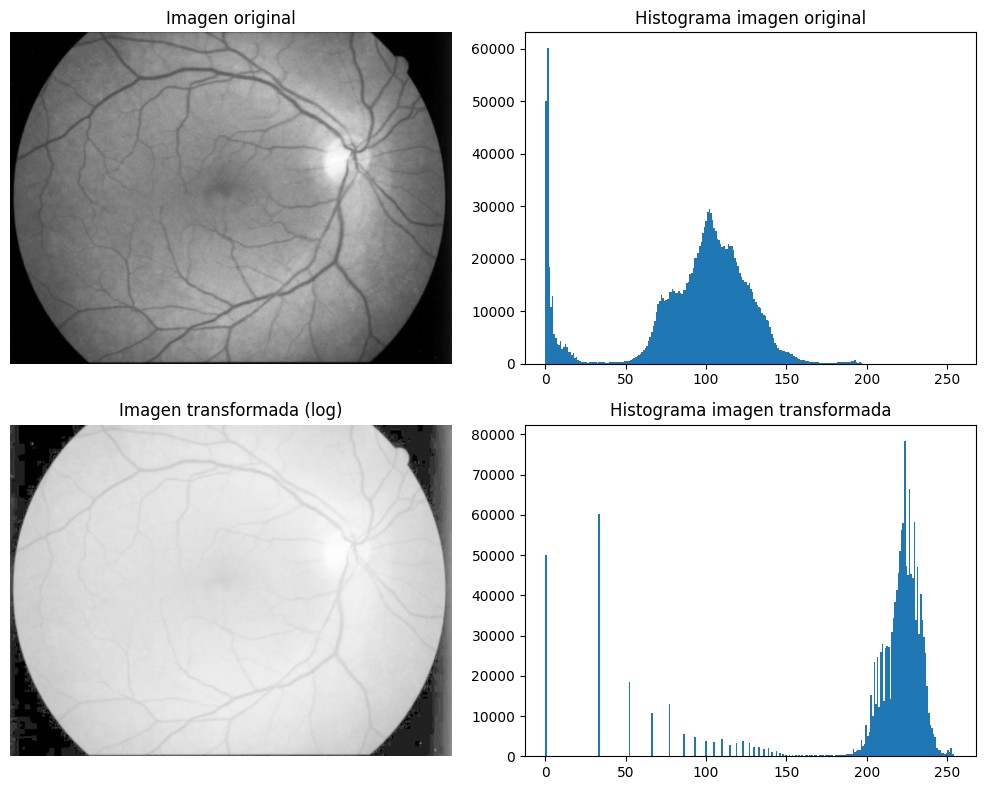

In [21]:
plt.figure(figsize=(10,8))

# Imagen original
plt.subplot(2,2,1)
plt.imshow(A, cmap='gray')
plt.title("Imagen original")
plt.axis("off")

# Histograma imagen original
plt.subplot(2,2,2)
plt.hist(A.ravel(), bins=256, range=(0,255))
plt.title("Histograma imagen original")

# Imagen transformada
plt.subplot(2,2,3)
plt.imshow(B_norm, cmap='gray')
plt.title("Imagen transformada (log)")
plt.axis("off")

# Histograma imagen transformada
plt.subplot(2,2,4)
plt.hist(B_norm.ravel(), bins=256, range=(0,255))
plt.title("Histograma imagen transformada")

plt.tight_layout()
plt.show()

El histograma de la imagen original muestra una concentración de intensidades en tonos medios. Después de aplicar la transformación logarítmica, las intensidades cambian a valores más altos, lo que aumenta el brillo de la imagen y mejora la visibilidad de regiones originalmente oscuras.

### Desafío final - Resaltando vasos sanguíneos

Diseñe una estrategia para resaltar vasos sanguíneos utilizando solo operaciones matemáticas sobre la matriz.

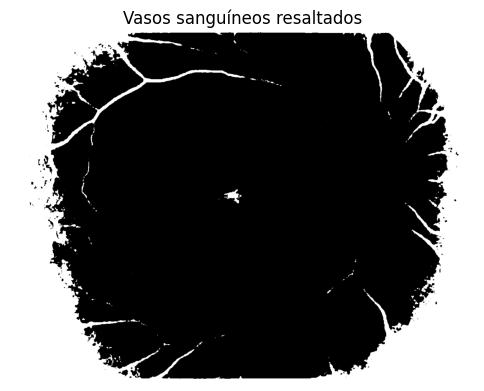

In [24]:
# 1. raíz cuadrada
B = np.sqrt(A)

# 2. normalizar a 0-255
B = (B - np.min(B)) / (np.max(B) - np.min(B)) * 255
B = B.astype(np.uint8)

# 3. invertir imagen
C = 255 - B

# 4. umbral automático usando la media
T = np.mean(C)

D = np.zeros(C.shape)

for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        if C[i,j] > T:
            D[i,j] = 255
        else:
            D[i,j] = 0

plt.figure(figsize=(6,6))
plt.imshow(D, cmap='gray')
plt.title("Vasos sanguíneos resaltados")
plt.axis("off")
plt.show()

Para resaltar los vasos sanguíneos se aplicó una transformación de raíz cuadrada para mejorar el contraste en regiones oscuras, seguida de una inversión de la imagen para que los vasos se representaran con intensidades altas. Finalmente se aplicó una umbralización basada en la media de la imagen para segmentar las estructuras vasculares.

***Preguntas:***

**1. ¿Qué transformación ayudó más a resaltar los vasos?** La transformación de raíz cuadrada combinada con la inversión de la imagen y la umbralización fue la que ayudó más a resaltar los vasos sanguíneos.
La raíz cuadrada permitió mejorar el contraste en las regiones oscuras, mientras que la inversión de la imagen hizo que los vasos sanguíneos se representaran como regiones claras, facilitando su detección mediante umbralización.

**2. ¿Por qué esa transformación funciona mejor?** Esta transformación funciona mejor porque los vasos sanguíneos tienen intensidades más bajas que el tejido circundante de la retina. La raíz cuadrada expande los valores de intensidad bajos, aumentando el contraste en las zonas oscuras. Posteriormente, al invertir la imagen, los vasos pasan a tener valores altos de intensidad, lo que permite separarlos del fondo mediante la umbralización.